# Generating Spatial Networks from Points

Spatial networks can be constructed from point data using a variety of connectivity models, including volume-exclusion, proximity-based, and constrained connection methods. SpaceNet supports each of these approaches, allowing spatial networks to be generated directly from a set of points.

In this tutorial, we'll use the `spatial_network_from_points()` function from the `utils` submodule to construct spatial networks. By default, `spatial_network_from_points()` uses the Delaunay triangulation connectivity model, a widely used volume-exclusion method. Let's start by generating a network from a random set of points and examine the resulting topology.


(<Figure size 640x480 with 1 Axes>, <Axes: >)

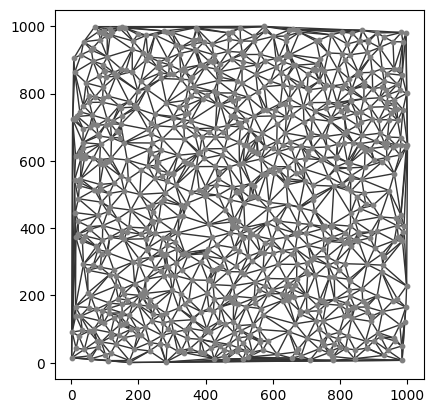

In [6]:
import spacenet as sn
import numpy as np

# generate a set a points 
points = np.random.rand(1000,2)*1000

# generate a spatial network from the points using the Delaunay model
spatial_net = sn.utils.spatial_network_from_points(points)

# visualise the network
sn.utils.plot_spatial_network(spatial_net)

The resulting network is the Delaunay triangulation of the input point set, where each point becomes a node and the triangulation defines the network connectivity.

A spatial network is simply a network whose nodes and edges have an associated spatial embedding. Each node stores its position in space, while each edge represents a spatial connection between two nodes and is weighted by the Euclidean distance separating them. We can inspect these spatial properties directly:


In [2]:
sn.utils.print_network_properties(spatial_net)

------------------
Network properties
------------------
Number of nodes: 1000
Number of edges: 2981
Edge weight names: ['Distance', 'Inverse Distance']
Node label names: ['position']
------------------


The network stores the spatial position of each node in the `position` attribute and the Euclidean distance associated with each edge in the `Distance` edge attribute. These edge weights can be visualized by specifying the `edge_weight_name` parameter in `plot_spatial_network()`.


(<Figure size 640x480 with 2 Axes>, <Axes: >)

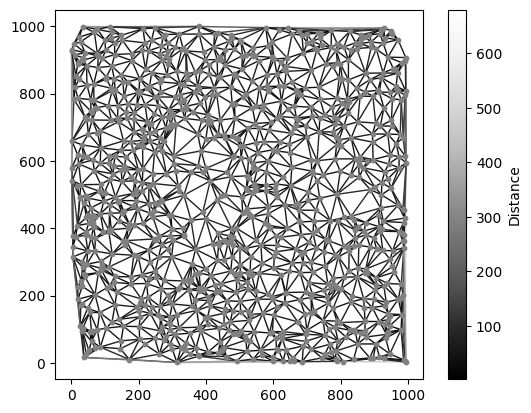

In [3]:
sn.utils.plot_spatial_network(spatial_net,edge_weight_name='Distance',add_edge_cbar=True)

The Delaunay triangulation can include relatively long edges that may not represent meaningful spatial connectivity in some applications. To address this, `spatial_network_from_points()` provides `max_edge_distance` and `min_edge_distance` parameters for filtering edges by length during network construction.

Let's regenerate the network, this time retaining only edges shorter than 100 distance units.


(<Figure size 640x480 with 1 Axes>, <Axes: >)

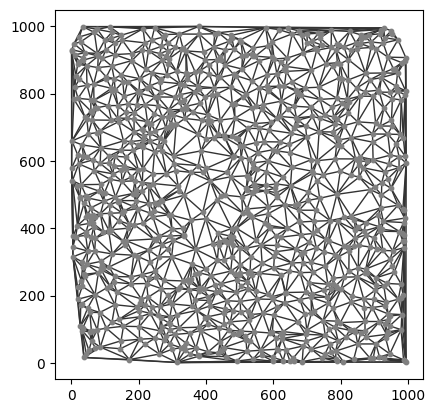

In [4]:
# generate a spatial network from the points using the Delaunay model
spatial_net_pruned = sn.utils.spatial_network_from_points(points,max_edge_distance=100)

# visualise the network
sn.utils.plot_spatial_network(spatial_net)

By filtering edges by length, we can tailor the network connectivity to better represent the spatial relationships in our data. These filtering options are equally applicable to three-dimensional point sets.

Let's repeat the previous example, this time using points embedded in 3D space.

(<Figure size 1000x800 with 1 Axes>, <Axes3D: >)

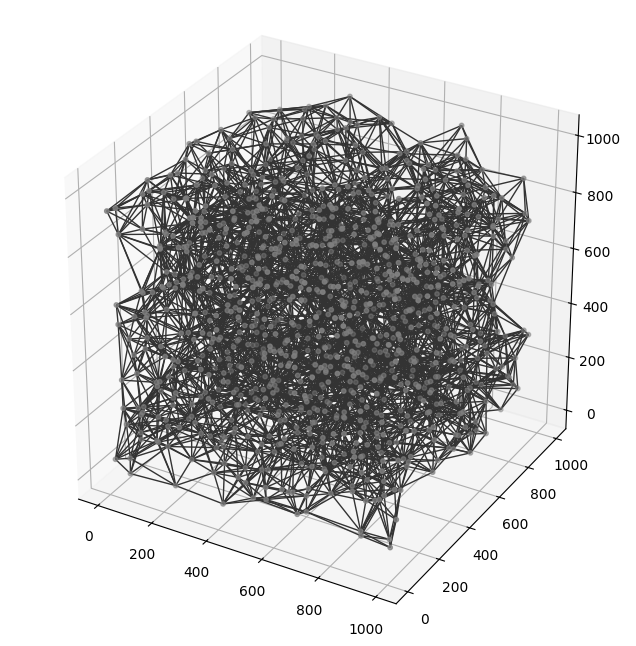

In [5]:
# generate a set a points 
points_3d = np.random.rand(1000,3)*1000

# generate a spatial network from the points using the Delaunay model
spatial_net_3d = sn.utils.spatial_network_from_points(points_3d,max_edge_distance=200)

# visualise the network
sn.utils.plot_spatial_network(spatial_net_3d)

In this tutorial, we've introduced the basic functionality for generating spatial networks from point data using the Delaunay triangulation connectivity model. SpaceNet also supports a range of alternative connectivity models, including proximity-based, *k*-nearest neighbour, relative neighbourhood, and others.

For details on all available connectivity models and their parameters, see the documentation for `spatial_network_from_points()`.
